In [1]:
from simulate import *

import matplotlib.pyplot as plt

DATA_DIR = "/dtu/projects/02613_2025/data/modified_swiss_dwellings/"
N = 4
with open(join(DATA_DIR, 'building_ids.txt'), 'r') as f:
    building_ids = f.read().splitlines()
print(len(building_ids))
building_ids = building_ids[:N]

# Load floor plans
all_u0 = np.empty((N, 514, 514))
all_interior_mask = np.empty((N, 512, 512), dtype='bool')
for i, bid in enumerate(building_ids):
    u0, interior_mask = load_data(DATA_DIR, bid)
    all_u0[i] = u0
    all_interior_mask[i] = interior_mask

# Run jacobi iterations for each floor plan
MAX_ITER = 20_000
ABS_TOL = 1e-4

4571


In [2]:
all_u = np.empty_like(all_u0)
for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
    u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
    all_u[i] = u

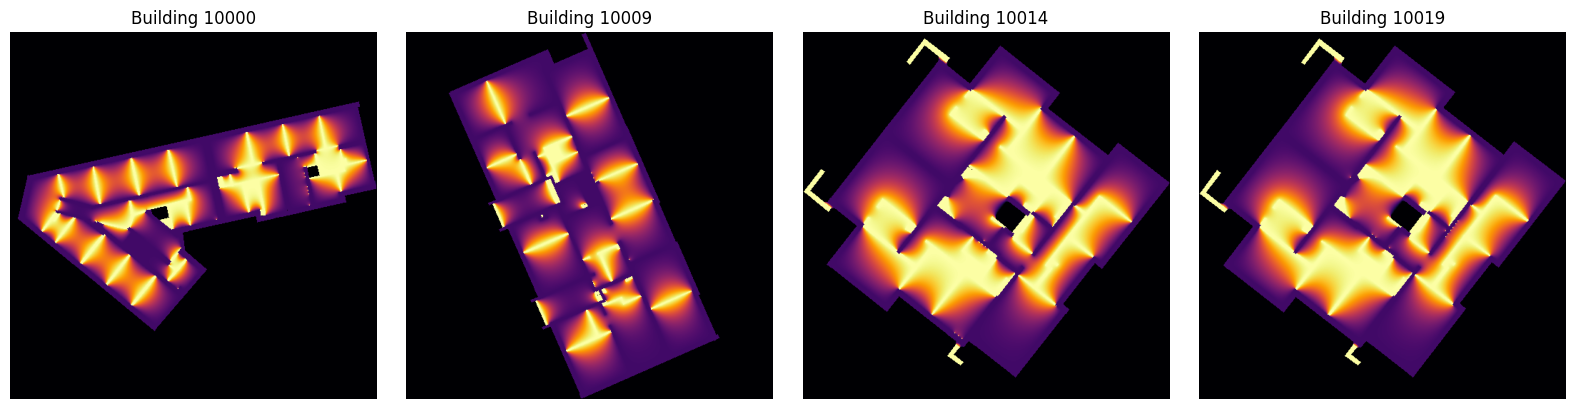

In [3]:
# Visualize the 4 buildings side by side
fig, axes = plt.subplots(1, N, figsize=(4 * N, 4))
for i in range(N):
    ax = axes[i]
    im = ax.imshow(all_u[i], cmap='inferno')
    ax.set_title(f"Building {building_ids[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

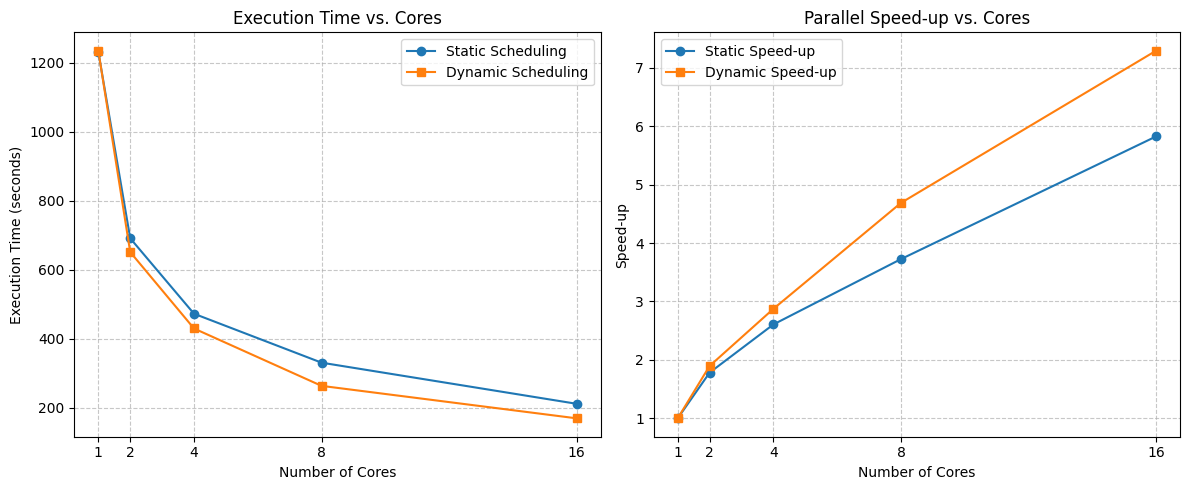

In [4]:
# Data
cores = [1, 2, 4, 8, 16]
static_times = [1232.48, 691.63, 472.85, 330.90, 211.62]
dynamic_times = [1235.59, 651.67, 430.02, 263.65, 169.47]

# Calculate speed-ups
static_speedup = [static_times[0] / t for t in static_times]
dynamic_speedup = [dynamic_times[0] / t for t in dynamic_times]

# Set up the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Execution Times Plot
ax1.plot(cores, static_times, marker='o', color='tab:blue', label='Static Scheduling')
ax1.plot(cores, dynamic_times, marker='s', color='tab:orange', label='Dynamic Scheduling')
ax1.set_xlabel('Number of Cores')
ax1.set_ylabel('Execution Time (seconds)')
ax1.set_title('Execution Time vs. Cores')
ax1.set_xticks(cores)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# 2. Speed-up Plot
ax2.plot(cores, static_speedup, marker='o', color='tab:blue', label='Static Speed-up')
ax2.plot(cores, dynamic_speedup, marker='s', color='tab:orange', label='Dynamic Speed-up')
ax2.set_xlabel('Number of Cores')
ax2.set_ylabel('Speed-up')
ax2.set_title('Parallel Speed-up vs. Cores')
ax2.set_xticks(cores)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

# Render
plt.tight_layout()
plt.show()

In [5]:
static_speedup, dynamic_speedup

([1.0,
  1.781993262293423,
  2.60649254520461,
  3.72462979752191,
  5.824024194310557],
 [1.0,
  1.8960363374100389,
  2.8733314729547463,
  4.686478285605917,
  7.290906945182038])

In [6]:
# Estimate parallel fraction
p_static = (1 - 1/static_speedup[-1])/(1 - 1/cores[-1])
p_dynamic = (1 - 1/dynamic_speedup[-1])/(1 - 1/cores[-1])
print(f"Estimated parallel fraction (dynamic scheduling): {p_dynamic*100:.2f}%")
print(f"Estimated parallel fraction (static scheduling): {p_static*100:.2f}%")

# Max speed-up according to Amdahl's Law
max_speedup_static = 1 / (1 - p_static)
max_speedup_dynamic = 1 / (1 - p_dynamic)
print(f"Estimated max speed-up (dynamic scheduling): {max_speedup_dynamic:.2f}x")
print(f"Estimated max speed-up (static scheduling): {max_speedup_static:.2f}x")

Estimated parallel fraction (dynamic scheduling): 92.04%
Estimated parallel fraction (static scheduling): 88.35%
Estimated max speed-up (dynamic scheduling): 12.56x
Estimated max speed-up (static scheduling): 8.58x


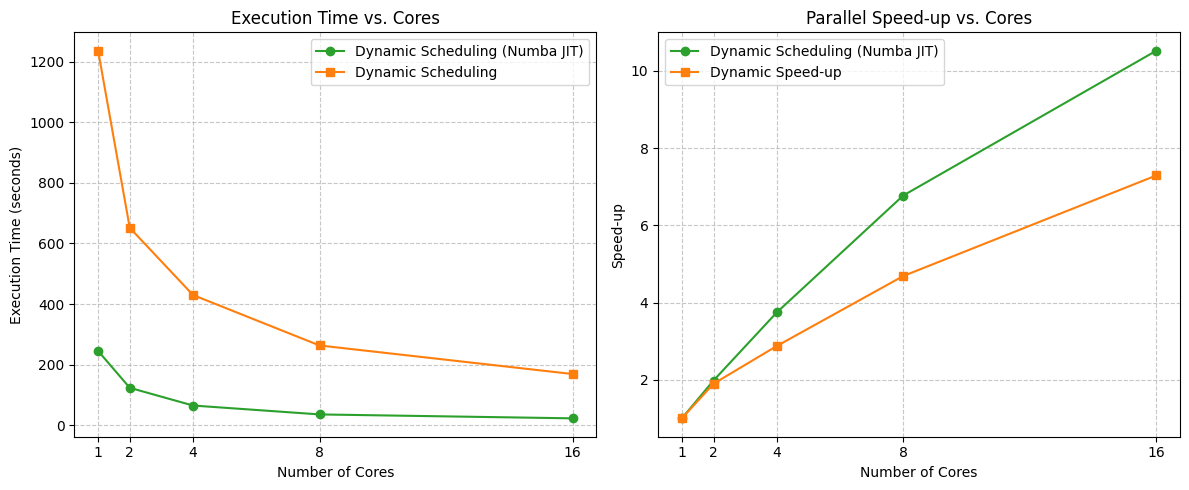

In [7]:
# Numba JIT vs Dynamic scheduling execution time / speed-up plots
numba_times = [245.48, 124.02, 65.58, 36.25, 23.33]

numba_speedup = [numba_times[0] / t for t in numba_times]

# Set up the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Execution Times Plot
ax1.plot(cores, numba_times, marker='o', color='tab:green', label='Dynamic Scheduling (Numba JIT)')
ax1.plot(cores, dynamic_times, marker='s', color='tab:orange', label='Dynamic Scheduling')
ax1.set_xlabel('Number of Cores')
ax1.set_ylabel('Execution Time (seconds)')
ax1.set_title('Execution Time vs. Cores')
ax1.set_xticks(cores)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# 2. Speed-up Plot
ax2.plot(cores, numba_speedup, marker='o', color='tab:green', label='Dynamic Scheduling (Numba JIT)')
ax2.plot(cores, dynamic_speedup, marker='s', color='tab:orange', label='Dynamic Speed-up')
ax2.set_xlabel('Number of Cores')
ax2.set_ylabel('Speed-up')
ax2.set_title('Parallel Speed-up vs. Cores')
ax2.set_xticks(cores)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

# Render
plt.tight_layout()
plt.show()